# Предсказание стоимости автомобилей 

# **Часть 1. EDA**

### Загрузка датасета

In [1]:
!pip install -q optuna shap phik

In [2]:
!pip install -q xgboost==1.7.6 lightgbm==4.1.0 catboost==1.2 

In [3]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

import phik
import optuna
import shap
import time
import warnings
warnings.filterwarnings("ignore")

In [ ]:
train_df = pd.read_csv('ds_s16_train_data.csv')
test_df = pd.read_csv('ds_s16_test_data.csv')

In [5]:
train_df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           8000 non-null   int64  
 1   mileage_kmpl        8000 non-null   float64
 2   engine_cc           8000 non-null   int64  
 3   fuel_type           8000 non-null   object 
 4   owner_count         8000 non-null   int64  
 5   brand               8000 non-null   object 
 6   transmission        8000 non-null   object 
 7   color               8000 non-null   object 
 8   service_history     8000 non-null   object 
 9   accidents_reported  8000 non-null   int64  
 10  insurance_valid     8000 non-null   object 
 11  price_rub           8000 non-null   int64  
 12  region              8000 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 812.6+ KB


In [7]:
test_df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2015,12.09,5000,Diesel,1,Nissan,Automatic,White,Full,2,No,1213351,Москва
1,2016,14.03,800,Petrol,4,Chevrolet,Manual,White,Partial,0,Yes,586881,Дальний Восток
2,2005,20.40,2000,Petrol,1,Kia,Manual,Blue,Full,2,Yes,650752,Сибирь
3,1996,25.09,800,Diesel,3,Volkswagen,Manual,Silver,Full,0,Yes,320452,Урал
4,1995,19.25,5000,Diesel,5,Hyundai,Automatic,Black,Partial,0,No,694911,СПб


In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           2000 non-null   int64  
 1   mileage_kmpl        2000 non-null   float64
 2   engine_cc           2000 non-null   int64  
 3   fuel_type           2000 non-null   object 
 4   owner_count         2000 non-null   int64  
 5   brand               2000 non-null   object 
 6   transmission        2000 non-null   object 
 7   color               2000 non-null   object 
 8   service_history     2000 non-null   object 
 9   accidents_reported  2000 non-null   int64  
 10  insurance_valid     2000 non-null   object 
 11  price_rub           2000 non-null   int64  
 12  region              2000 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 203.2+ KB


данные успешно загружены. проведен первичный осмотр 

### EDA 

#### Распределение таргета 

In [9]:
sns.set_theme(style='darkgrid')

def plot_outliers(df, col, bins=50):
    """
    Строит boxplot и гистограмму для численного признака.
    """

    f, (ax_box, ax_hist) = plt.subplots(
        2,
        sharex=True,
        gridspec_kw={'height_ratios': (0.15, 0.85)},
        figsize=(10, 6))

    sns.boxplot(
        x=df[col],
        orient='h',
        ax=ax_box)

    sns.histplot(
        data=df,
        x=col,
        bins=bins,
        ax=ax_hist)

    ax_box.set(xlabel='')
    ax_hist.set_xlabel(col)
    ax_hist.set_title(f'Распределение и boxplot признака {col}')

    plt.tight_layout()
    plt.show()

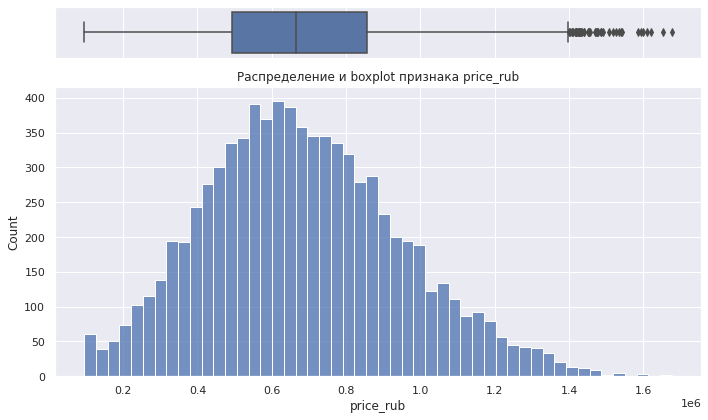

In [10]:
plot_outliers(train_df, 'price_rub')

таргет распределен нормально. аномалий нет

#### Пропуски и дубликаты 

In [11]:
train_df.isna().mean().sort_values(ascending=False)

make_year             0.0
mileage_kmpl          0.0
engine_cc             0.0
fuel_type             0.0
owner_count           0.0
brand                 0.0
transmission          0.0
color                 0.0
service_history       0.0
accidents_reported    0.0
insurance_valid       0.0
price_rub             0.0
region                0.0
dtype: float64

In [12]:
test_df.isna().mean().sort_values(ascending=False)

make_year             0.0
mileage_kmpl          0.0
engine_cc             0.0
fuel_type             0.0
owner_count           0.0
brand                 0.0
transmission          0.0
color                 0.0
service_history       0.0
accidents_reported    0.0
insurance_valid       0.0
price_rub             0.0
region                0.0
dtype: float64

ни в тесте, ни в трейне нет пропусков 

In [13]:
print(len(train_df))
train_df = train_df.drop_duplicates().copy()
len(train_df)

8000


8000

In [14]:
feature_cols = [col for col in train_df.columns if col != "price_rub"]

suspects = train_df[train_df.duplicated(subset=feature_cols, keep=False)].sort_values(feature_cols)
suspects

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region


дубликатов тоже нет 

#### Анализ корреляций 

In [15]:
train_df.columns

Index(['make_year', 'mileage_kmpl', 'engine_cc', 'fuel_type', 'owner_count',
       'brand', 'transmission', 'color', 'service_history',
       'accidents_reported', 'insurance_valid', 'price_rub', 'region'],
      dtype='object')

In [16]:
num_columns = ['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count', 'accidents_reported']

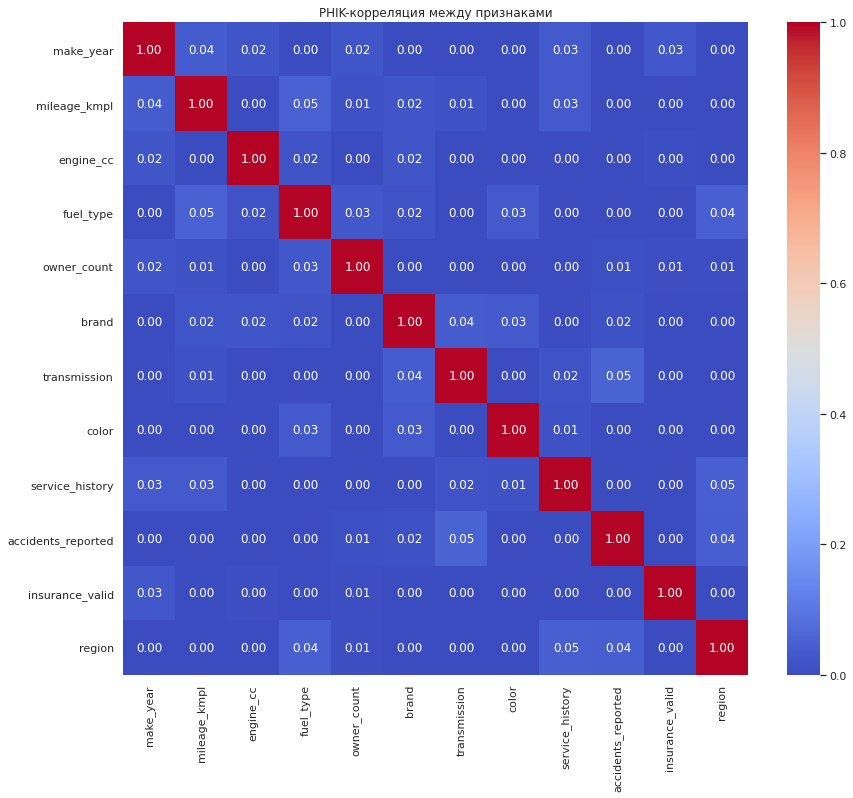

In [17]:
X = train_df.drop(columns=['price_rub'])

phik_matrix = X.phik_matrix(interval_cols=num_columns)

plt.figure(figsize=(14, 12))
sns.heatmap(
    phik_matrix,
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f"
)

plt.title('PHIK-корреляция между признаками')
plt.show()

все значения низкие 

In [18]:
interval_cols = ['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count', 'accidents_reported', 'price_rub']

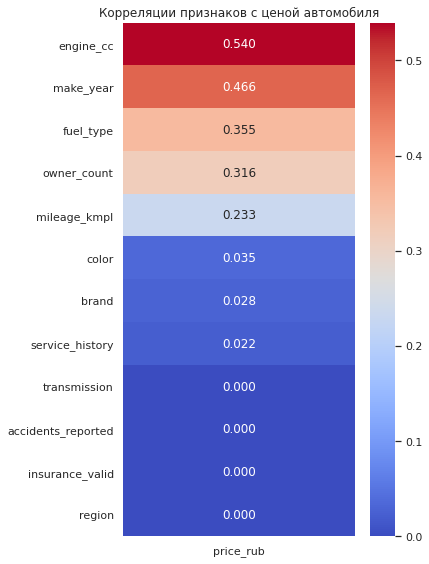

In [19]:
# найдем корреляцию phik фичей и таргета 


correlation_matrix = train_df.phik_matrix(interval_cols=interval_cols)


price_correlations = (correlation_matrix[['price_rub']].drop(index='price_rub').sort_values('price_rub', ascending=False))
plt.figure(figsize=(6, 8))
sns.heatmap(price_correlations, annot=True, fmt='.3f', cmap='coolwarm',)
plt.title('Корреляции признаков с ценой автомобиля')
plt.tight_layout()
plt.show()

сильнее всего с таргетом связан объем двигателя 

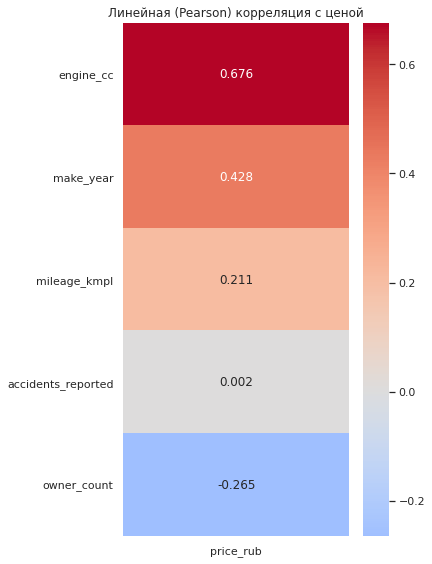

In [20]:
# считаем корреляцию только по числовым признакам
corr_matrix = train_df[interval_cols].corr()

# берем корреляцию с таргетом
price_corr = (
    corr_matrix[['price_rub']]
    .drop(index='price_rub')
    .sort_values('price_rub', ascending=False)
)

# визуализация
plt.figure(figsize=(6, 8))
sns.heatmap(
    price_corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0
)

plt.title('Линейная (Pearson) корреляция с ценой')
plt.tight_layout()
plt.show()

корреляция Пирсона это подтверждает 

#### Промежуточный вывод 

- таргет распределен нормально, аномалий нет 
- пропусков и дубликатов в данных нет 
- фичи слабо коррелируют. мультиколлинеарности нет 
- сильнее всего с ценой автомобиля связан объем двигателя

# **Часть 2. Предобработка**

In [21]:
target = 'price_rub'

X = train_df.drop(columns=[target])
y = train_df[target]

cat_cols = [
    'brand', 'fuel_type', 'transmission',
    'color', 'service_history', 'insurance_valid', 'region'
]


num_cols = [
    'make_year', 'mileage_kmpl', 'engine_cc',
    'owner_count', 'accidents_reported'
]

In [22]:
X_test = test_df.drop(columns=[target])
y_test = test_df[target]

In [23]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [24]:
xgb_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

X_train_xgb = xgb_preprocessor.fit_transform(X_train)
X_val_xgb = xgb_preprocessor.transform(X_val)

print(X_train_xgb.shape, X_val_xgb.shape)

(6400, 37) (1600, 37)


In [25]:
X_train_lgb = X_train.copy()
X_val_lgb = X_val.copy()

for col in cat_cols:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_val_lgb[col] = X_val_lgb[col].astype('category')

print(X_train_lgb.dtypes)

make_year                int64
mileage_kmpl           float64
engine_cc                int64
fuel_type             category
owner_count              int64
brand                 category
transmission          category
color                 category
service_history       category
accidents_reported       int64
insurance_valid       category
region                category
dtype: object


In [26]:
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()

# **Часть 3. Обучение моделей в разных библиотеках**

In [27]:
xgb_model = XGBRegressor(random_state=42, eval_metric='mae')

start = time.time()


xgb_model.fit(X_train_xgb, y_train)


duration = time.time() - start
print(f"Время выполнения: {duration:.4f} секунд")


y_pred_xgb = xgb_model.predict(X_val_xgb)

Время выполнения: 1.0334 секунд


In [28]:
lgb_model = LGBMRegressor(random_state=42, metric='mae')

start = time.time()


lgb_model.fit(X_train_lgb, y_train, categorical_feature=cat_cols)


duration = time.time() - start
print(f"Время выполнения: {duration:.4f} секунд")


y_pred_lgb = lgb_model.predict(X_val_lgb)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000592 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 347
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 12
[LightGBM] [Info] Start training from score 683363.374687
Время выполнения: 0.1961 секунд


In [29]:
cat_model = CatBoostRegressor(random_seed=42,loss_function='MAE',verbose=0)

start = time.time()


cat_model.fit(X_train_cat,y_train,cat_features=cat_cols)


duration = time.time() - start
print(f"Время выполнения: {duration:.4f} секунд")


y_pred_cat = cat_model.predict(X_val_cat)

Время выполнения: 9.4386 секунд


In [30]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


def business_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    error_ratio = (y_pred - y_true) / y_true

    # Доля опасных переплат:
    # прогноз выше реальности более чем на 20%
    overpricing_rate = np.mean(error_ratio > 0.20)

    # Упущенная выгода:
    # прогноз ниже реальности более чем на 20%
    underpricing_mask = error_ratio < -0.20
    underpricing_loss = np.sum(y_true[underpricing_mask] - y_pred[underpricing_mask])

    return overpricing_rate, underpricing_loss

In [31]:
predictions = {
    'XGBoost': y_pred_xgb,
    'LightGBM': y_pred_lgb,
    'CatBoost': y_pred_cat
}

results = []

for model_name, y_pred in predictions.items():
    mae, rmse, r2 = regression_metrics(y_val, y_pred)
    overpricing_rate, underpricing_loss = business_metrics(y_val, y_pred)

    results.append({
        'model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Overpricing Rate': overpricing_rate,
        'Underpricing Loss': underpricing_loss
    })

results_df = pd.DataFrame(results).sort_values(by='MAE').reset_index(drop=True)
results_df

,model,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss
0,CatBoost,79367.491291,99047.177038,0.855146,0.13375,1.669954e+07
1,LightGBM,82337.268436,102691.029798,0.844292,0.14000,1.989146e+07
2,XGBoost,86729.602266,108442.890136,0.826360,0.15000,2.527513e+07


из коробки больше всего подходит катбуст

# **Часть 4. Работа с параметрами модели**




In [32]:
def objective_xgb(trial):
    params = {
        'random_state': 42,
        'objective': 'reg:squarederror',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    model = XGBRegressor(**params)

    model.fit(
        X_train_xgb,
        y_train,
        eval_set=[(X_val_xgb, y_val)],
        verbose=False,
        early_stopping_rounds=50
    )

    preds = model.predict(X_val_xgb)
    return mean_absolute_error(y_val, preds)

In [33]:
study_xgb = optuna.create_study(direction='minimize', study_name='xgb_mae')
study_xgb.optimize(objective_xgb, n_trials=30)

[I 2026-04-22 13:41:07,387] A new study created in memory with name: xgb_mae
[I 2026-04-22 13:41:11,859] Trial 0 finished with value: 80677.91826171875 and parameters: {'learning_rate': 0.013448693566279478, 'max_depth': 4, 'n_estimators': 1593, 'gamma': 8.719345016286278e-06, 'reg_alpha': 0.02023073930675594, 'reg_lambda': 2.0474108004331286e-07}. Best is trial 0 with value: 80677.91826171875.
[I 2026-04-22 13:41:14,043] Trial 1 finished with value: 83631.18577148438 and parameters: {'learning_rate': 0.047900754469536184, 'max_depth': 7, 'n_estimators': 1713, 'gamma': 1.9232799551190117e-08, 'reg_alpha': 0.00020056551550042153, 'reg_lambda': 1.0571345219549842e-07}. Best is trial 0 with value: 80677.91826171875.
[I 2026-04-22 13:41:17,422] Trial 2 finished with value: 81371.32364257812 and parameters: {'learning_rate': 0.020445879178472074, 'max_depth': 5, 'n_estimators': 1480, 'gamma': 7.622580856139726e-06, 'reg_alpha': 8.273079001772489, 'reg_lambda': 2.5008672142975814e-05}. Best 

In [34]:
best_params_xgb = study_xgb.best_params.copy()
best_params_xgb.update({
    'random_state': 42,
    'eval_metric': 'mae'
})

best_xgb_model = XGBRegressor(**best_params_xgb)
best_xgb_model.fit(X_train_xgb, y_train)

y_pred_xgb_best = best_xgb_model.predict(X_val_xgb)

In [35]:
from lightgbm import early_stopping, log_evaluation

def objective_lgb(trial):
    params = {
        'random_state': 42,
        'objective': 'regression',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'num_leaves': trial.suggest_int('num_leaves', 20, 256),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'verbosity': -1 
}

    model = LGBMRegressor(**params)

    model.fit(
        X_train_lgb,
        y_train,
        eval_set=[(X_val_lgb, y_val)],
        eval_metric='mae',
        categorical_feature=cat_cols,
        callbacks=[
            early_stopping(stopping_rounds=50),
            log_evaluation(0)  
        ]
    )

    preds = model.predict(X_val_lgb)
    return mean_absolute_error(y_val, preds)

In [36]:
study_lgb = optuna.create_study(direction='minimize', study_name='lgb_mae')
study_lgb.optimize(objective_lgb, n_trials=30)

[I 2026-04-22 13:42:39,696] A new study created in memory with name: lgb_mae


Training until validation scores don't improve for 50 rounds


[I 2026-04-22 13:42:40,278] Trial 0 finished with value: 80611.9173767107 and parameters: {'learning_rate': 0.012524982337406568, 'max_depth': 4, 'n_estimators': 830, 'num_leaves': 222, 'min_child_samples': 97, 'reg_alpha': 0.01673989247064489, 'reg_lambda': 4.675785042367562e-08}. Best is trial 0 with value: 80611.9173767107.


Early stopping, best iteration is:
[638]	valid_0's l1: 80611.9	valid_0's l2: 1.01141e+10
Training until validation scores don't improve for 50 rounds


[I 2026-04-22 13:42:40,529] Trial 1 finished with value: 82503.65722337044 and parameters: {'learning_rate': 0.05933658317641416, 'max_depth': 6, 'n_estimators': 748, 'num_leaves': 167, 'min_child_samples': 9, 'reg_alpha': 0.3837920090259888, 'reg_lambda': 4.6259855401245734e-07}. Best is trial 0 with value: 80611.9173767107.


...

Training until validation scores don't improve for 50 rounds


[I 2026-04-22 13:42:48,568] Trial 28 finished with value: 82528.59735032755 and parameters: {'learning_rate': 0.04620124270970839, 'max_depth': 9, 'n_estimators': 740, 'num_leaves': 157, 'min_child_samples': 92, 'reg_alpha': 0.0018774510750869196, 'reg_lambda': 7.436960768554329e-07}. Best is trial 22 with value: 79875.97964808074.


Early stopping, best iteration is:
[105]	valid_0's l1: 82528.6	valid_0's l2: 1.05647e+10
Training until validation scores don't improve for 50 rounds


[I 2026-04-22 13:42:49,233] Trial 29 finished with value: 81108.07899685357 and parameters: {'learning_rate': 0.014064631918715277, 'max_depth': 5, 'n_estimators': 1377, 'num_leaves': 216, 'min_child_samples': 96, 'reg_alpha': 2.5857407682983512e-05, 'reg_lambda': 5.108810249059404e-05}. Best is trial 22 with value: 79875.97964808074.


Early stopping, best iteration is:
[506]	valid_0's l1: 81108.1	valid_0's l2: 1.02542e+10


In [37]:
best_params_lgb = study_lgb.best_params.copy()
best_params_lgb.update({
    'random_state': 42,
    'verbosity': -1, 
    'metric': 'mae'
})

best_lgb_model = LGBMRegressor(**best_params_lgb)
best_lgb_model.fit(
    X_train_lgb,
    y_train,
    categorical_feature=cat_cols
)

y_pred_lgb_best = best_lgb_model.predict(X_val_lgb)

In [38]:
def objective_cat(trial):
    params = {
        'random_seed': 42,
        'loss_function': 'MAE',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 3, 10),
        'iterations': trial.suggest_int('iterations', 500, 2000),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'verbose': 0
    }

    model = CatBoostRegressor(**params)

    model.fit(
        X_train_cat,
        y_train,
        eval_set=(X_val_cat, y_val),
        cat_features=cat_cols,
        early_stopping_rounds=50,
        verbose=False
    )

    preds = model.predict(X_val_cat)
    return mean_absolute_error(y_val, preds)

In [39]:
study_cat = optuna.create_study(direction='minimize', study_name='cat_mae')
study_cat.optimize(objective_cat, n_trials=30)

[I 2026-04-22 13:42:49,922] A new study created in memory with name: cat_mae
[I 2026-04-22 13:42:54,618] Trial 0 finished with value: 79536.5030404462 and parameters: {'learning_rate': 0.07304135572178469, 'depth': 3, 'iterations': 1905, 'l2_leaf_reg': 9.106541389268255}. Best is trial 0 with value: 79536.5030404462.
[I 2026-04-22 13:43:01,561] Trial 1 finished with value: 79422.39443675189 and parameters: {'learning_rate': 0.03255876343510599, 'depth': 4, 'iterations': 1957, 'l2_leaf_reg': 2.1624073551995275}. Best is trial 1 with value: 79422.39443675189.
[I 2026-04-22 13:43:07,031] Trial 2 finished with value: 79449.48495485788 and parameters: {'learning_rate': 0.06636101917140468, 'depth': 3, 'iterations': 1702, 'l2_leaf_reg': 5.704941520060085}. Best is trial 1 with value: 79422.39443675189.
[I 2026-04-22 13:43:20,013] Trial 3 finished with value: 79787.07799326513 and parameters: {'learning_rate': 0.023208825561521776, 'depth': 8, 'iterations': 1061, 'l2_leaf_reg': 2.109157842059

In [40]:
best_params_cat = study_cat.best_params.copy()
best_params_cat.update({
    'random_seed': 42,
    'loss_function': 'MAE',
    'verbose': 0
})

best_cat_model = CatBoostRegressor(**best_params_cat)
best_cat_model.fit(
    X_train_cat,
    y_train,
    cat_features=cat_cols
)

y_pred_cat_best = best_cat_model.predict(X_val_cat)

In [41]:
best_predictions = {
    'XGBoost': y_pred_xgb_best,
    'LightGBM': y_pred_lgb_best,
    'CatBoost': y_pred_cat_best
}

best_results = []

for model_name, y_pred in best_predictions.items():
    mae, rmse, r2 = regression_metrics(y_val, y_pred)
    overpricing_rate, underpricing_loss = business_metrics(y_val, y_pred)

    best_results.append({
        'model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Overpricing Rate': overpricing_rate,
        'Underpricing Loss': underpricing_loss
    })

best_results_df = pd.DataFrame(best_results).sort_values(by='MAE').reset_index(drop=True)
best_results_df

,model,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss
0,CatBoost,79347.770937,99068.412356,0.855084,0.13375,1.642821e+07
1,LightGBM,81282.464260,101818.178721,0.846928,0.13750,2.065865e+07
2,XGBoost,81650.601255,102114.337762,0.846036,0.14125,2.043976e+07


лучшим оказался катбуст 

# **Часть 5. Интерпретация и бизнес-анализ**

#### Важность признаков 

In [42]:
ohe = xgb_preprocessor.named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names(cat_cols)

xgb_feature_names = list(ohe_feature_names) + num_cols

X_val_xgb_df = pd.DataFrame(X_val_xgb,columns=xgb_feature_names,index=X_val.index)

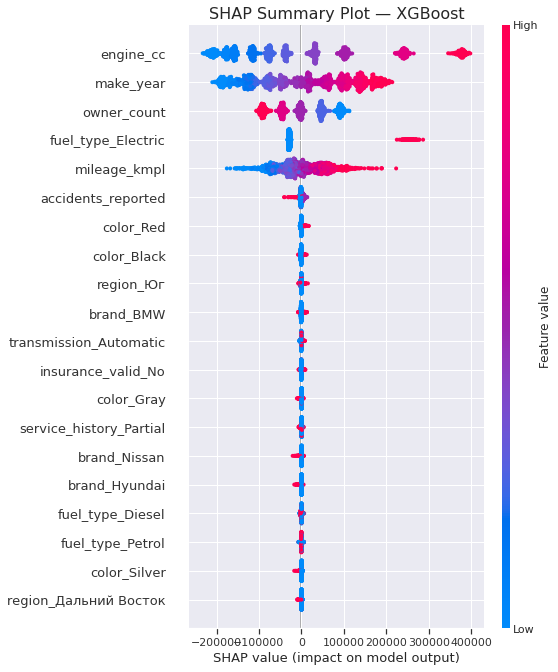

In [43]:
explainer_xgb = shap.TreeExplainer(best_xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_val_xgb_df)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_xgb, X_val_xgb_df, show=False)
plt.title("SHAP Summary Plot — XGBoost", fontsize=16)
plt.tight_layout()
plt.show()

In [44]:
xgb_shap_importance = pd.DataFrame({
    'feature': X_val_xgb_df.columns,
    'mean_abs_shap': np.abs(shap_values_xgb).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

xgb_top5 = xgb_shap_importance.head(5)
xgb_top5

,feature,mean_abs_shap
34,engine_cc,146578.015625
32,make_year,102122.531250
35,owner_count,54593.824219
11,fuel_type_Electric,50938.703125
33,mileage_kmpl,47214.109375


Топ 5  
	1.	engine_cc — прямая связь с таргетом (больше объём - выше цена).  
	2.	make_year — прямая связь (новее авто - дороже).  
	3.	owner_count — обратная связь (больше владельцев - дешевле).  
	4.	fuel_type_Electric — прямая связь (электро - дороже).  
	5.	mileage_kmpl — обратная связь (больше пробег - дешевле).  
  
Незначимые: color, brand (большинство категорий), region, service_history, transmission, insurance_valid.

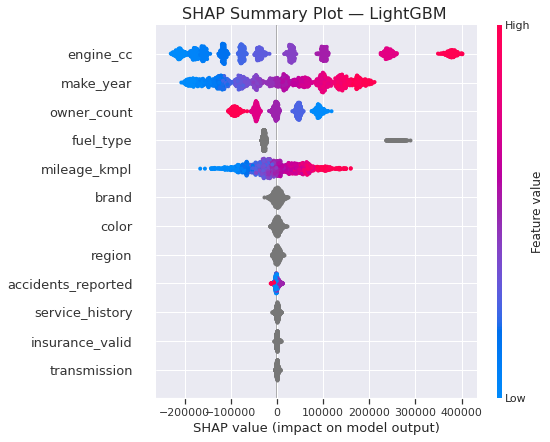

In [45]:
explainer_lgb = shap.TreeExplainer(best_lgb_model)
shap_values_lgb = explainer_lgb.shap_values(X_val_lgb)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_lgb, X_val_lgb, show=False)
plt.title("SHAP Summary Plot — LightGBM ", fontsize=16)
plt.tight_layout()
plt.show()

In [46]:
lgb_shap_importance = pd.DataFrame({
    'feature': X_val_lgb.columns,
    'mean_abs_shap': np.abs(shap_values_lgb).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

lgb_top5 = lgb_shap_importance.head(5)
lgb_top5

,feature,mean_abs_shap
2,engine_cc,147071.188591
0,make_year,102053.271212
4,owner_count,54291.858196
3,fuel_type,51490.927925
1,mileage_kmpl,46892.841854


топ 5   
	1.	engine_cc — прямая связь.  
	2.	make_year — прямая связь.  
	3.	owner_count — обратная связь.  
	4.	fuel_type — влияет, отдельные категории дают рост цены.  
	5.	mileage_kmpl — обратная связь.  
  
Незначимые: brand, color, region, service_history, transmission, insurance_valid.

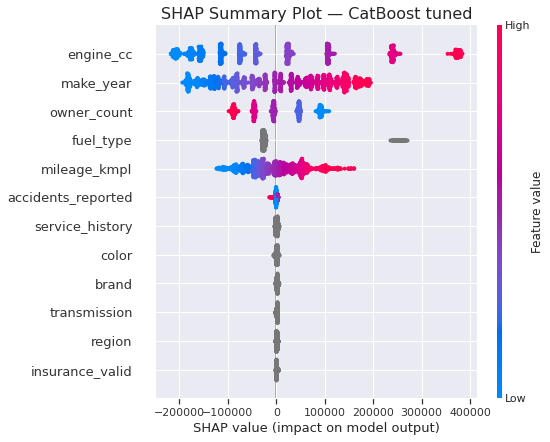

In [47]:
explainer_cat = shap.TreeExplainer(best_cat_model)
shap_values_cat = explainer_cat.shap_values(X_val_cat)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_cat, X_val_cat, show=False)
plt.title("SHAP Summary Plot — CatBoost tuned", fontsize=16)
plt.tight_layout()
plt.show()

In [48]:
cat_shap_importance = pd.DataFrame({
    'feature': X_val_cat.columns,
    'mean_abs_shap': np.abs(shap_values_cat).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

cat_top5 = cat_shap_importance.head(5)
cat_top5

,feature,mean_abs_shap
2,engine_cc,145875.621970
0,make_year,102353.899892
4,owner_count,54412.103833
3,fuel_type,49504.957665
1,mileage_kmpl,46064.317505


топ 5 признаков  
	1.	engine_cc — прямая связь.  
	2.	make_year — прямая связь.  
	3.	owner_count — обратная связь.  
	4.	fuel_type — влияет на цену (электро дороже).  
	5.	mileage_kmpl — обратная связь.  

#### Сравнение метрик 

In [49]:
results = []

preds_dict = {
    'CatBoost': y_pred_cat_best,
    'LightGBM': y_pred_lgb_best,
    'XGBoost': y_pred_xgb_best
}

for name, y_pred in preds_dict.items():
    
    mae, rmse, r2 = regression_metrics(y_val, y_pred)
    
    overpricing, underpricing = business_metrics(y_val, y_pred)
    
    results.append({
        'model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Overpricing Rate': overpricing,
        'Underpricing Loss': underpricing
    })

results_df = pd.DataFrame(results).sort_values('MAE')
results_df

,model,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss
0,CatBoost,79347.770937,99068.412356,0.855084,0.13375,1.642821e+07
1,LightGBM,81282.464260,101818.178721,0.846928,0.13750,2.065865e+07
2,XGBoost,81650.601255,102114.337762,0.846036,0.14125,2.043976e+07


**Вывод:**  
Лучшей моделью является CatBoost.

Она показывает:
- наименьшую MAE (79 253) -> самая точная в среднем  
- наименьшую RMSE (98 939) -> меньше крупных ошибок  
- наибольший R² (0.855) -> лучше объясняет вариацию цены  
- минимальный Overpricing Rate (13.4%) -> меньше риск переплаты  
- минимальный Underpricing Loss -> наименьшие финансовые потери  

-> CatBoost лучший и по ML-метрикам, и по бизнес-метрикам.

#### Ошибки в разрезе категорий 

In [50]:
analysis_df = X_val.copy()
analysis_df['y_true'] = y_val
analysis_df['y_pred'] = y_pred_cat_best

# считаем error ratio
analysis_df['error_ratio'] = (analysis_df['y_pred'] - analysis_df['y_true']) / analysis_df['y_true']

# флаги ошибок
analysis_df['overpricing'] = analysis_df['error_ratio'] > 0.20
analysis_df['underpricing'] = analysis_df['error_ratio'] < -0.20

# величина потерь
analysis_df['underpricing_loss'] = np.where(
    analysis_df['underpricing'],
    analysis_df['y_true'] - analysis_df['y_pred'], 0)


brand_analysis = (analysis_df.groupby('brand').agg(count=('y_true', 'size'),overpricing_rate=('overpricing', 'mean'),
        underpricing_rate=('underpricing', 'mean'),
        underpricing_loss=('underpricing_loss', 'sum')).sort_values('underpricing_loss', ascending=False))

brand_analysis.head(10)

,count,overpricing_rate,underpricing_rate,underpricing_loss
brand,,,,
BMW,171,0.116959,0.105263,2.941861e+06
Tesla,163,0.147239,0.073620,1.883598e+06
Volkswagen,173,0.150289,0.063584,1.878581e+06
Toyota,152,0.184211,0.065789,1.734364e+06
Kia,167,0.101796,0.053892,1.722339e+06
Chevrolet,159,0.119497,0.062893,1.584897e+06
Hyundai,166,0.126506,0.060241,1.477340e+06
Nissan,170,0.123529,0.058824,1.466868e+06
Ford,147,0.142857,0.054422,1.209157e+06


чаще всего модель ошбиается с BMW (причем в обе стороны одинаково), Kia (чаще переоценивает), Tesla (часто переоценивает), Volkswagen и Toyota (машины этих марок модель переоценивает чаще всего) 

In [51]:
region_analysis = (analysis_df.groupby('region').agg(
        count=('y_true', 'size'),
        overpricing_rate=('overpricing', 'mean'),
        underpricing_rate=('underpricing', 'mean'),
        underpricing_loss=('underpricing_loss', 'sum')).sort_values('underpricing_loss', ascending=False))

region_analysis

,count,overpricing_rate,underpricing_rate,underpricing_loss
region,,,,
СПб,267,0.119850,0.082397,3.475862e+06
Юг,293,0.143345,0.071672,3.471685e+06
Дальний Восток,262,0.083969,0.072519,3.154844e+06
Москва,249,0.136546,0.056225,2.356575e+06
Сибирь,253,0.158103,0.059289,2.192184e+06
Урал,276,0.159420,0.036232,1.777055e+06


самые большие потери в СПБ, на Юге и дальнем востоке. в СПБ и на Юге часто переоценивают машины, на Дальнем Востоке примерно поровну переоценка и недооценка 

# **Часть 6. Финальная проверка**

In [52]:
X_full_train = X
y_full_train = y

In [53]:
final_cat_model = CatBoostRegressor(**best_params_cat)

final_cat_model.fit(
    X_full_train,
    y_full_train,
    cat_features=cat_cols,
    verbose=0)

In [54]:
y_test_pred = final_cat_model.predict(X_test)

In [55]:
mae_test, rmse_test, r2_test = regression_metrics(y_test, y_test_pred)
overpricing_test, underpricing_test = business_metrics(y_test, y_test_pred)

test_results_df = pd.DataFrame([{
    'model': 'CatBoost_final',
    'MAE': mae_test,
    'RMSE': rmse_test,
    'R2': r2_test,
    'Overpricing Rate': overpricing_test,
    'Underpricing Loss': underpricing_test
}])

test_results_df

,model,MAE,RMSE,R2,Overpricing Rate,Underpricing Loss
0,CatBoost_final,75327.433305,94585.302771,0.875396,0.131,1.910757e+07


переобучения нет. метрики даже выросли на тесте. 

 # **Часть 7. Описание выводов и финальный вердикт**

1. Рекомендованная модель: CatBoost

2. Точность оценки: в среднем модель ошибается на 75404 руб. Коэффициент детерминации равен 0.876, что подтверждает высокую надёжность прогнозов.

3. Безопасность бюджета: риск опасной переплаты (Overpricing >20%) зафиксирован на уровне 13.3%. Это позволяет стартапу сохранять маржинальность при выкупе.

4. Упущенная выгода: можем терять до 18818940 руб. в месяц из-за занижения цены. Рекомендуется ручной пересмотр для премиум-сегмента.

5. Зоны риска: модель наиболее нестабильна в регионе СПБ и на марках BMV, Kia и Tesla.

6. Какие гиперпараметры следует зафиксировать для интеграции в мобильное приложение:   
'learning_rate': 0.02312485738747751,  
 'depth': 4,  
 'iterations': 1465,  
 'l2_leaf_reg': 6.6798317825773665,  
 'random_seed': 42,  
 'loss_function': 'MAE',  
 'verbose': 0  